📖 Loading dataset...
✅ WT Reference Atlas: 121379 cells
✅ 5xFAD Query Dataset: 79495 cells
⚙️ Processing WT Reference space (PCA, Neighbors, UMAP)...
🎯 Projecting 5xFAD query onto WT Reference space (Label Transfer)...


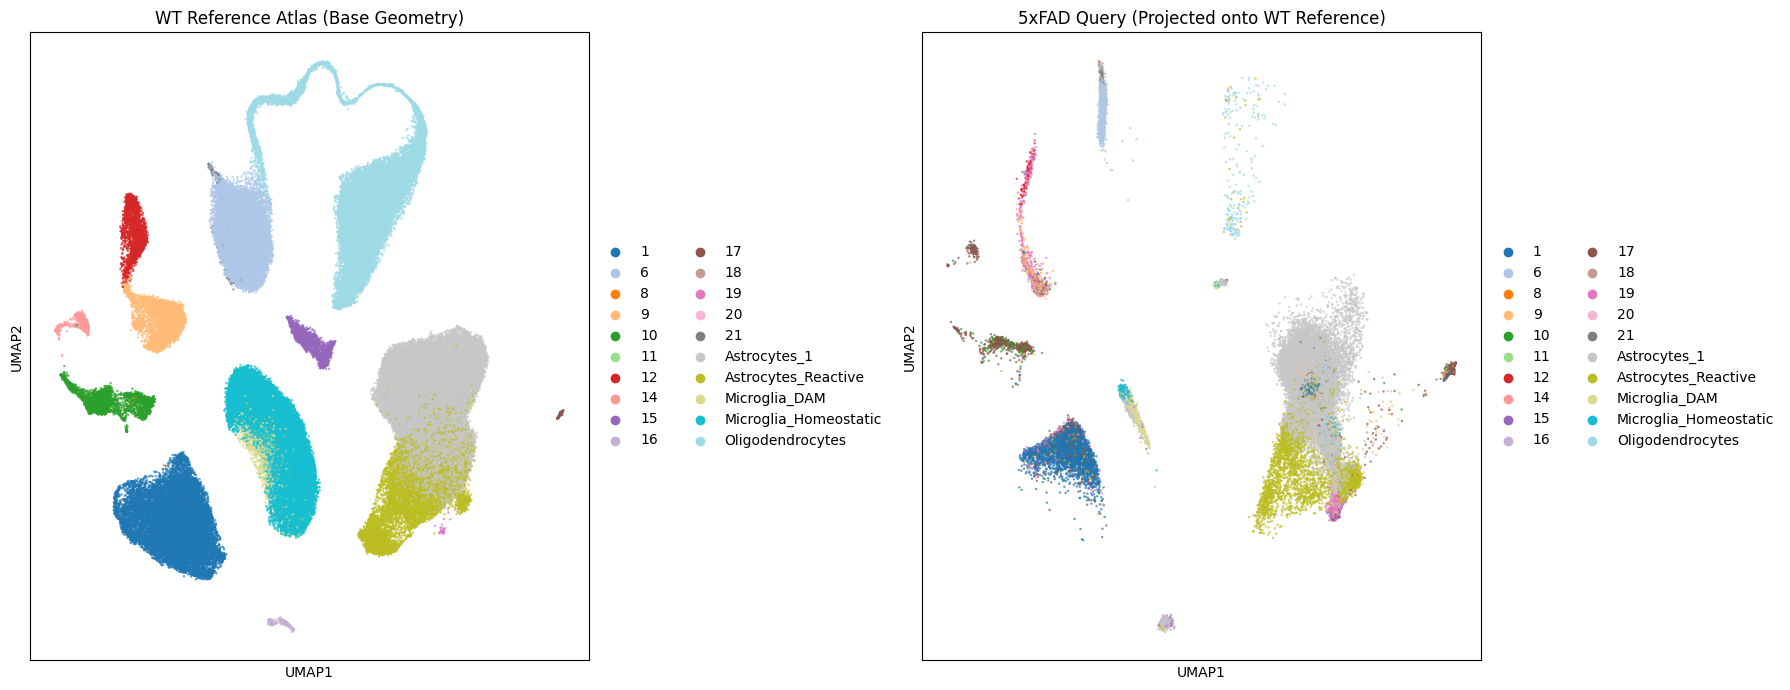

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

# ==========================================
# 1. Load Combined Dataset
# ==========================================
print("📖 Loading dataset...")
adata_combined = sc.read_h5ad("5xFAD_WT_Integrated_Annotated.h5ad")

# Identify condition metadata column
cond_col = next(
    (
        c
        for c in ["condition", "batch_source", "batch", "sample"]
        if c in adata_combined.obs.columns
    ),
    "condition",
)

wt_mask = (
    adata_combined.obs[cond_col]
    .astype(str)
    .str.contains("WT|Control|Atlas", case=False)
)

# Separate into Reference (WT) and Query (5xFAD)
adata_ref = adata_combined[wt_mask].copy()
adata_query = adata_combined[~wt_mask].copy()

print(f"✅ WT Reference Atlas: {adata_ref.n_obs} cells")
print(f"✅ 5xFAD Query Dataset: {adata_query.n_obs} cells")

# ==========================================
# 2. Build Unbiased WT Reference Manifold
# ==========================================
print("⚙️ Processing WT Reference space (PCA, Neighbors, UMAP)...")
sc.pp.highly_variable_genes(adata_ref, n_top_genes=2000, subset=False)
sc.tl.pca(adata_ref, svd_solver="arpack")
sc.pp.neighbors(adata_ref, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_ref)

# ==========================================
# 3. Project 5xFAD Query onto Reference Space
# ==========================================
print("🎯 Projecting 5xFAD query onto WT Reference space (Label Transfer)...")

# Intersect genes present in both datasets
common_genes = adata_ref.var_names.intersection(adata_query.var_names)
adata_ref = adata_ref[:, common_genes].copy()
adata_query = adata_query[:, common_genes].copy()

# Set annotation label to map
target_label = "cell_type_annotated"

# Perform spatial projection & label transfer
sc.tl.ingest(adata_query, adata_ref, obs=target_label)

# ==========================================
# 4. Plot Side-by-Side Comparison
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# WT Base Reference Manifold
sc.pl.umap(
    adata_ref,
    color=target_label,
    ax=axes[0],
    show=False,
    title="WT Reference Atlas (Base Geometry)",
    size=12,
    alpha=0.7,
    palette="tab20",
    legend_loc="right margin",
)

# Projected 5xFAD Query
sc.pl.umap(
    adata_query,
    color=target_label,
    ax=axes[1],
    show=False,
    title="5xFAD Query (Projected onto WT Reference)",
    size=12,
    alpha=0.7,
    palette="tab20",
    legend_loc="right margin",
)

plt.tight_layout()
plt.show()